In [26]:
#import packages 

import pandas as pd
import matplotlib.pyplot as plt
import scipy as sc
import numpy as np
from scipy.stats import linregress
import cartopy.crs as ccrs
import seaborn as sns
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import xarray as xr
import matplotlib.colors as mcolors


In [10]:
#reading files 

# sedimentary pteropods

ds = pd.read_excel('Pteropod_summary_MeCa.xlsx', sheet_name= 'Summary') 

# water column pteropods

dw = pd.read_excel('Pteropod_summary_MeCa.xlsx', sheet_name= 'Water Column Batch Analysis') 

dnw = pd.read_excel('Pteropod_summary_MeCa.xlsx', sheet_name = 'water column excluding nans')



In [20]:
#create csv to index cleaning types

dscsv = "Pteropod_summary_MeCa.csv"

ds.to_csv(dscsv, index=False)

dscsv = pd.read_csv(dscsv)

In [24]:
#index data by cleaning type or water column 

noclean = dscsv[dscsv['Cleaning'].str.contains('no clean')]
sonic = dscsv[dscsv['Cleaning'].str.contains('sonic only')]
redsonic = dscsv[dscsv['Cleaning'].str.contains('sonic+red', regex=False)]
oxredsonic = dscsv[dscsv['Cleaning'].str.contains('sonic++red+ox', regex=False)]
waterptero = dscsv[dscsv['Cleaning'].str.contains('na')]

Text(0.5, 1.0, 'Pteropod Sample Locations')

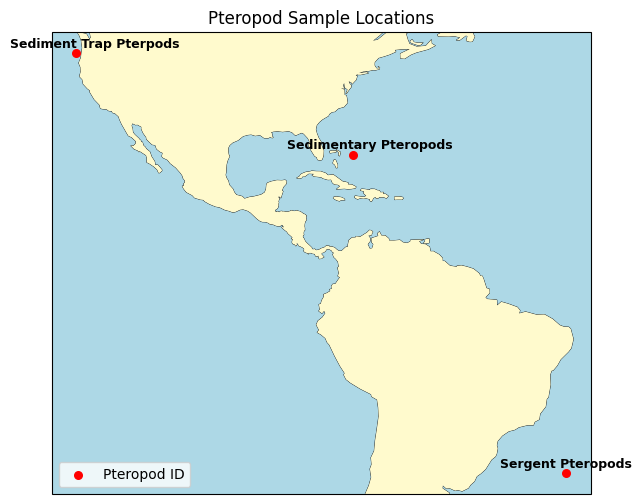

In [38]:
#Graph 1: Map for Pteropod Datasets

#create figure
plt.figure(figsize=(10,6))

#plot projection
ax = plt.axes(projection=ccrs.PlateCarree())

#plot land, coastlines, and ocean features
ax.add_feature(cfeature.LAND, facecolor='lemonchiffon', zorder=2)
ax.add_feature(cfeature.COASTLINE, zorder=1, linewidth=0.5)
ax.add_feature(cfeature.OCEAN, color='lightblue')

#add stations and station ids
station_lons = [-74.7, -125, -36.02 ]  
station_lats = [26.14, 44.583, -31.65]
station_id = ['Sedimentary Pteropods','Sediment Trap Pterpods', 'Sergent Pteropods']

#scatter plot stations
ax.scatter(station_lons, station_lats, color='red', s=30, transform=ccrs.PlateCarree(), label='Pteropod ID', zorder=3)

#add legend
ax.legend(loc='lower left')

#add station labels 
for lon, lat, name in zip(station_lons, station_lats, station_id):
    ax.text(lon - 12, lat + 1, name, color='black', fontsize=9,
            transform=ccrs.PlateCarree(), zorder=4, fontweight='bold')

#set title
ax.set_title('Pteropod Sample Locations')

In [52]:
#index variables

# getting U nmols/ Ca mols from each cleaning type 
nocleanU = noclean['U/Ca [nmol/mol]']
sonicU = sonic['U/Ca [nmol/mol]']
redsonicU = redsonic['U/Ca [nmol/mol]']
oxredsonicU = oxredsonic['U/Ca [nmol/mol]']
waterpteroU = waterptero['U/Ca [nmol/mol]']
#combining U data
cleantypeU = [nocleanU, sonicU, redsonicU, oxredsonicU, waterpteroU]

# getting Mg mmols/ Ca mols from each cleaning type 
nocleanMg = noclean['Mg_Ca [mmol/mol]']
sonicMg = sonic['Mg_Ca [mmol/mol]']
redsonicMg = redsonic['Mg_Ca [mmol/mol]']
oxredsonicMg = oxredsonic['Mg_Ca [mmol/mol]']
waterpteroMg = waterptero['Mg_Ca [mmol/mol]'].dropna().values.flatten()
#combining Mg data
cleantypeMg = nocleanMg, sonicMg, redsonicMg, oxredsonicMg, waterpteroMg

# getting Sr mmols/ Ca mols from each cleaning type 
nocleanSr = noclean['Sr/Ca [mmol/mol]']
sonicSr = sonic['Sr/Ca [mmol/mol]']
redsonicSr = redsonic['Sr/Ca [mmol/mol]']
oxredsonicSr = oxredsonic['Sr/Ca [mmol/mol]']
waterpteroSr = waterptero['Sr/Ca [mmol/mol]']
#combining Sr data
cleantypeSr = nocleanSr, sonicSr, redsonicSr, oxredsonicSr, waterpteroSr

# getting Ba umols/ Ca mols from each cleaning type 
nocleanBa = noclean['Ba/Ca [umol/mol]']
sonicBa = sonic['Ba/Ca [umol/mol]']
redsonicBa = redsonic['Ba/Ca [umol/mol]']
oxredsonicBa = oxredsonic['Ba/Ca [umol/mol]']
waterpteroBa = waterptero['Ba/Ca [umol/mol]']
#combining Ba data
cleantypeBa = nocleanBa, sonicBa, redsonicBa, oxredsonicBa, waterpteroBa

# getting Na mmols/ Ca mols from each cleaning type 
nocleanNa = noclean['Na_Ca [mmol/mol]']
sonicNa = sonic['Na_Ca [mmol/mol]']
redsonicNa = redsonic['Na_Ca [mmol/mol]']
oxredsonicNa = oxredsonic['Na_Ca [mmol/mol]']
waterpteroNa = waterptero['Na_Ca [mmol/mol]'].dropna().values.flatten()
#combining Na data
cleantypeNa = nocleanNa, sonicNa, redsonicNa, oxredsonicNa, waterpteroNa

# getting Mn umols/ Ca mols from each cleaning type 
nocleanMn = noclean['Mn_Ca [umol/mol]']
sonicMn = sonic['Mn_Ca [umol/mol]']
redsonicMn = redsonic['Mn_Ca [umol/mol]']
oxredsonicMn = oxredsonic['Mn_Ca [umol/mol]']
waterpteroMn = waterptero['Mn_Ca [umol/mol]'].dropna().values.flatten()
#combining Mn data
cleantypeMn = nocleanMn, sonicMn, redsonicMn, oxredsonicMn, waterpteroMn

# getting Fe umols/ Ca mols from each cleaning type 
nocleanFe = noclean['Fe_Ca [umol/mol]']
sonicFe = sonic['Fe_Ca [umol/mol]']
redsonicFe = redsonic['Fe_Ca [umol/mol]']
oxredsonicFe = oxredsonic['Fe_Ca [umol/mol]']
waterpteroFe = waterptero['Fe_Ca [umol/mol]'].dropna().values.flatten()
#combining Fe data
cleantypeFe = nocleanFe, sonicFe, redsonicFe, oxredsonicFe, waterpteroFe

# getting Al umols/ Ca mols from each cleaning type 
nocleanAl = noclean['Al_Ca [umol/mol]']
sonicAl = sonic['Al_Ca [umol/mol]']
redsonicAl = redsonic['Al_Ca [umol/mol]']
oxredsonicAl = oxredsonic['Al_Ca [umol/mol]']
waterpteroAl = waterptero['Al_Ca [umol/mol]'].dropna().values.flatten()
#combine Al data
cleantypeAl = nocleanAl, sonicAl, redsonicAl, oxredsonicAl, waterpteroAl

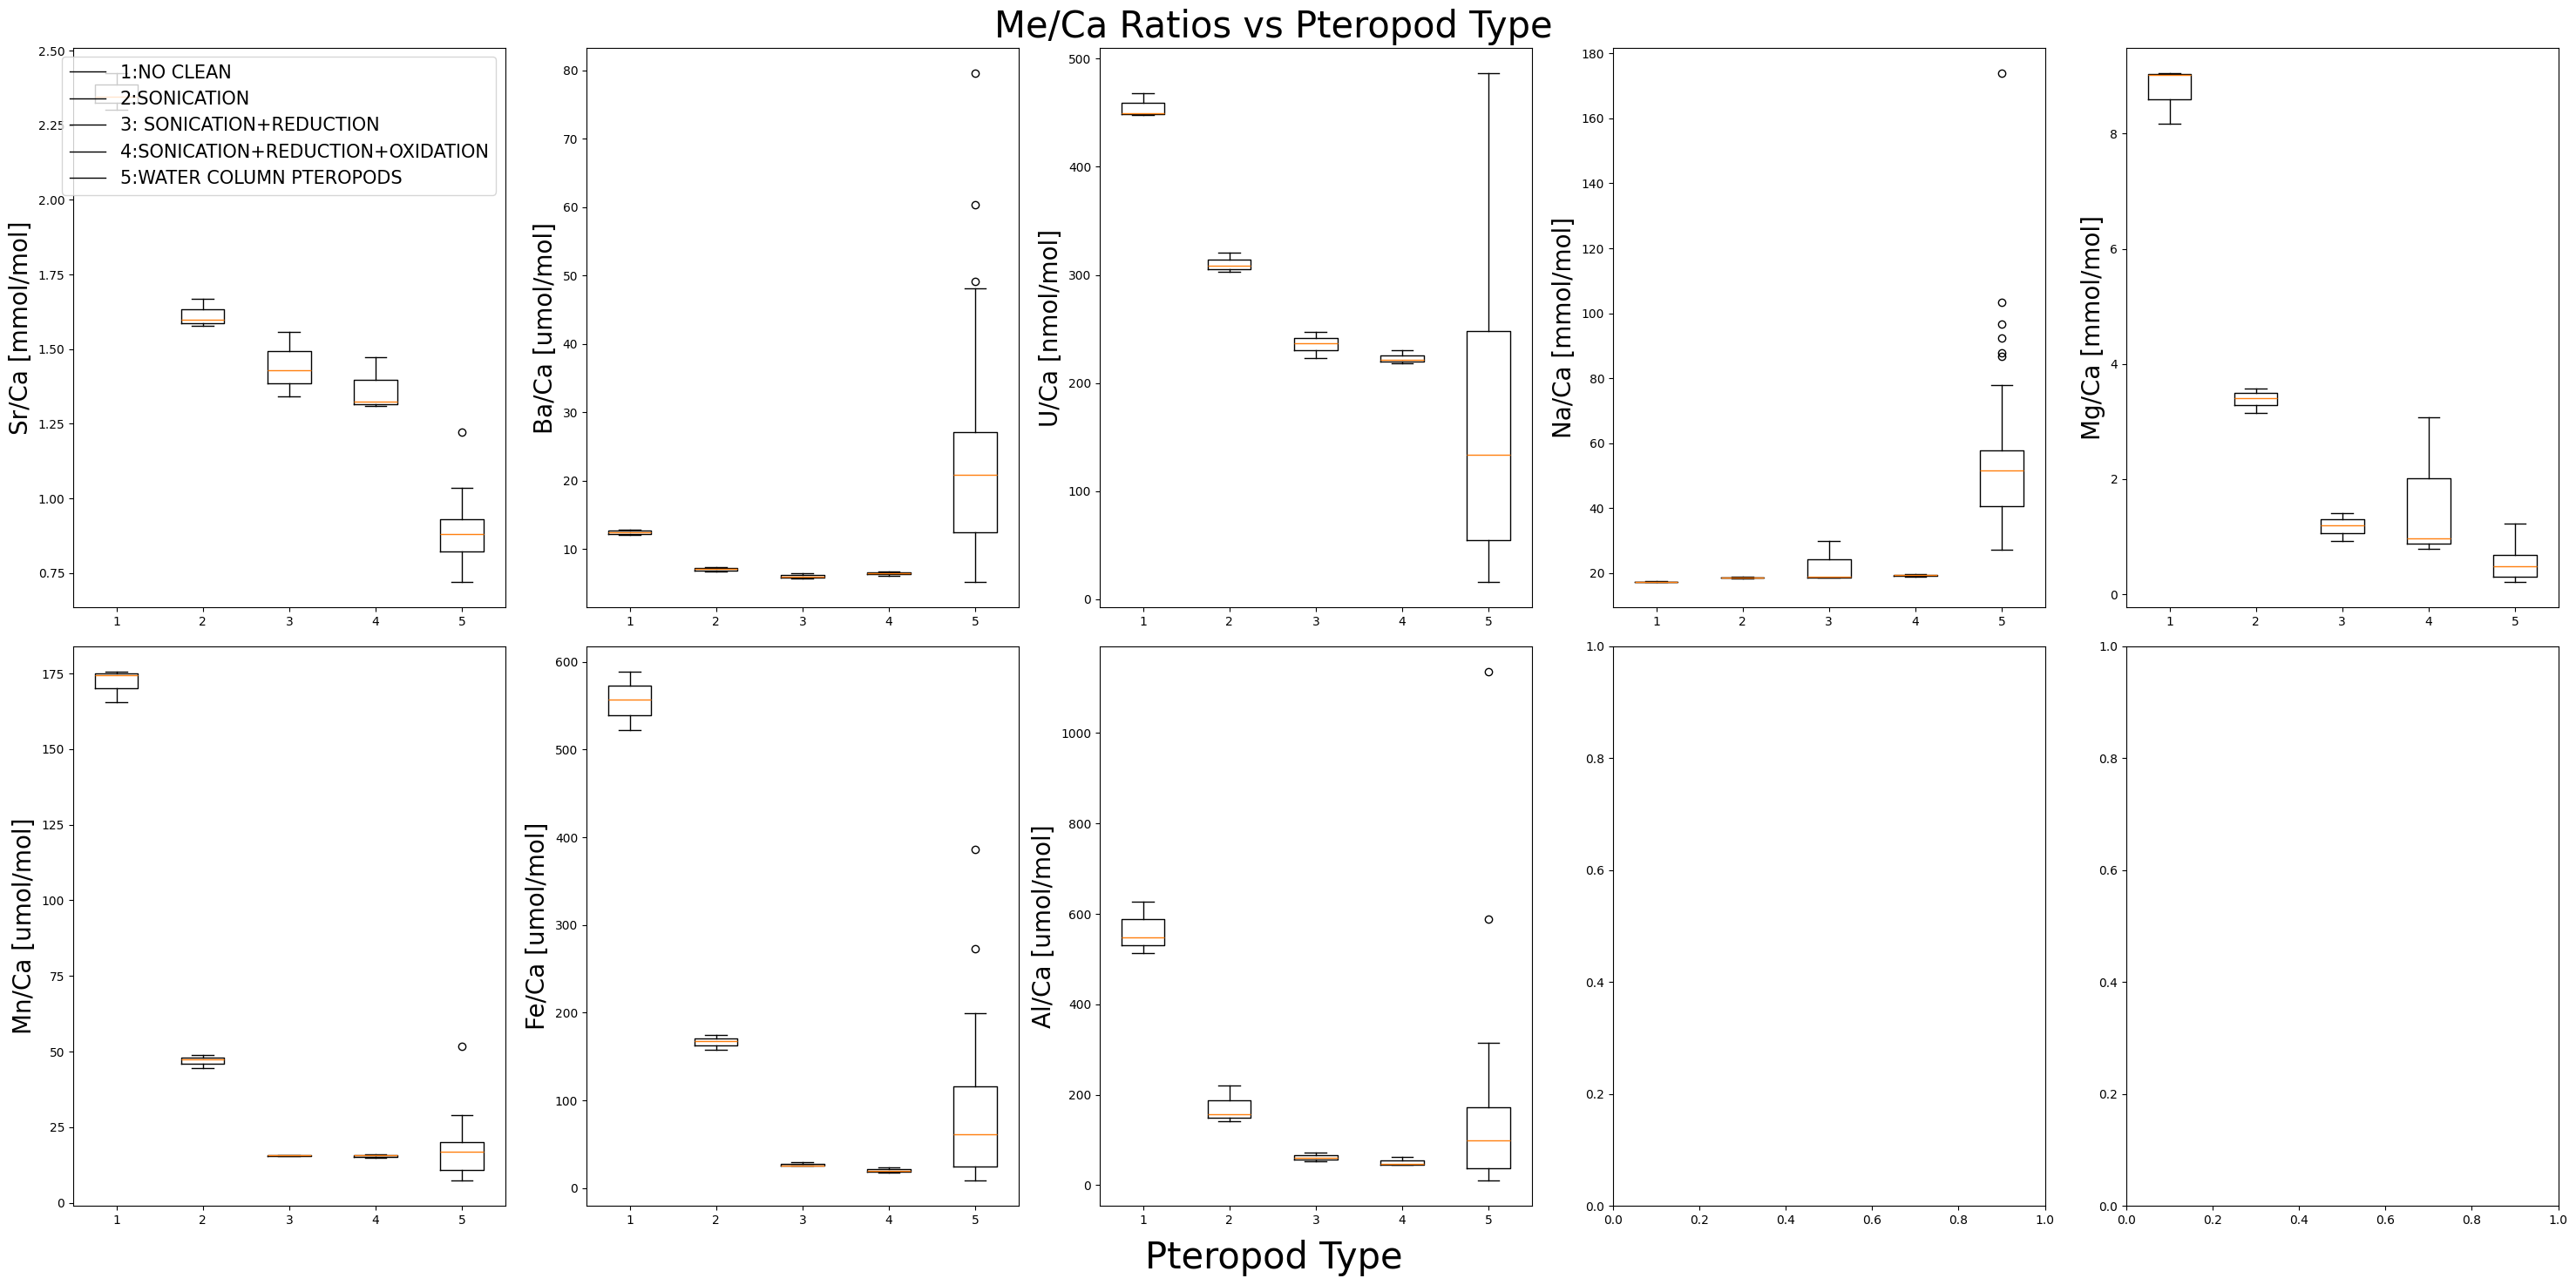

In [58]:
#Graph 2: combined Me/Ca ratios vs different cleaning types sedimentary pterods and water column pteropods 

#create figure
fig, axes = plt.subplots(2, 5, figsize=(30, 15), sharex=False, sharey=False)
ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9, ax10 = axes.flatten()

#plot boxplots for combined data
ax1.boxplot(cleantypeSr)

ax2.boxplot(cleantypeBa)

ax3.boxplot(cleantypeU)

ax4.boxplot(cleantypeNa)

ax5.boxplot(cleantypeMg)

ax6.boxplot(cleantypeMn)

ax7.boxplot(cleantypeFe) 

ax8.boxplot(cleantypeAl)

#label axes
ax1.set_ylabel('Sr/Ca [mmol/mol]', fontsize=20)
ax1.set_xlabel('')

ax2.set_ylabel('Ba/Ca [umol/mol]', fontsize=20)
ax2.set_xlabel('')

ax3.set_ylabel('U/Ca [nmol/mol]', fontsize=20)
ax3.set_xlabel('')

ax4.set_ylabel('Na/Ca [mmol/mol]', fontsize=20)
ax4.set_xlabel('')

ax5.set_ylabel('Mg/Ca [mmol/mol]', fontsize=20)
ax5.set_xlabel('')

ax6.set_ylabel('Mn/Ca [umol/mol]', fontsize=20)
ax6.set_xlabel('')

ax7.set_ylabel('Fe/Ca [umol/mol]', fontsize=20)
ax7.set_xlabel('')

ax8.set_ylabel('Al/Ca [umol/mol]', fontsize=20)
ax8.set_xlabel('')



#plot title
fig.suptitle('Me/Ca Ratios vs Pteropod Type', fontsize = 30)
fig.supxlabel('Pteropod Type', fontsize= 30)
# fig.supylabel('Me/Ca Ratios', fontsize= 30)
lab = '1:NO CLEAN', '2:SONICATION', '3: SONICATION+REDUCTION', '4:SONICATION+REDUCTION+OXIDATION', '5:WATER COLUMN PTEROPODS'
#set legend
ax1.legend(lab, fontsize = 15)

#fixing spacing layout
fig.tight_layout()

#add grid lines
# ax1.grid()



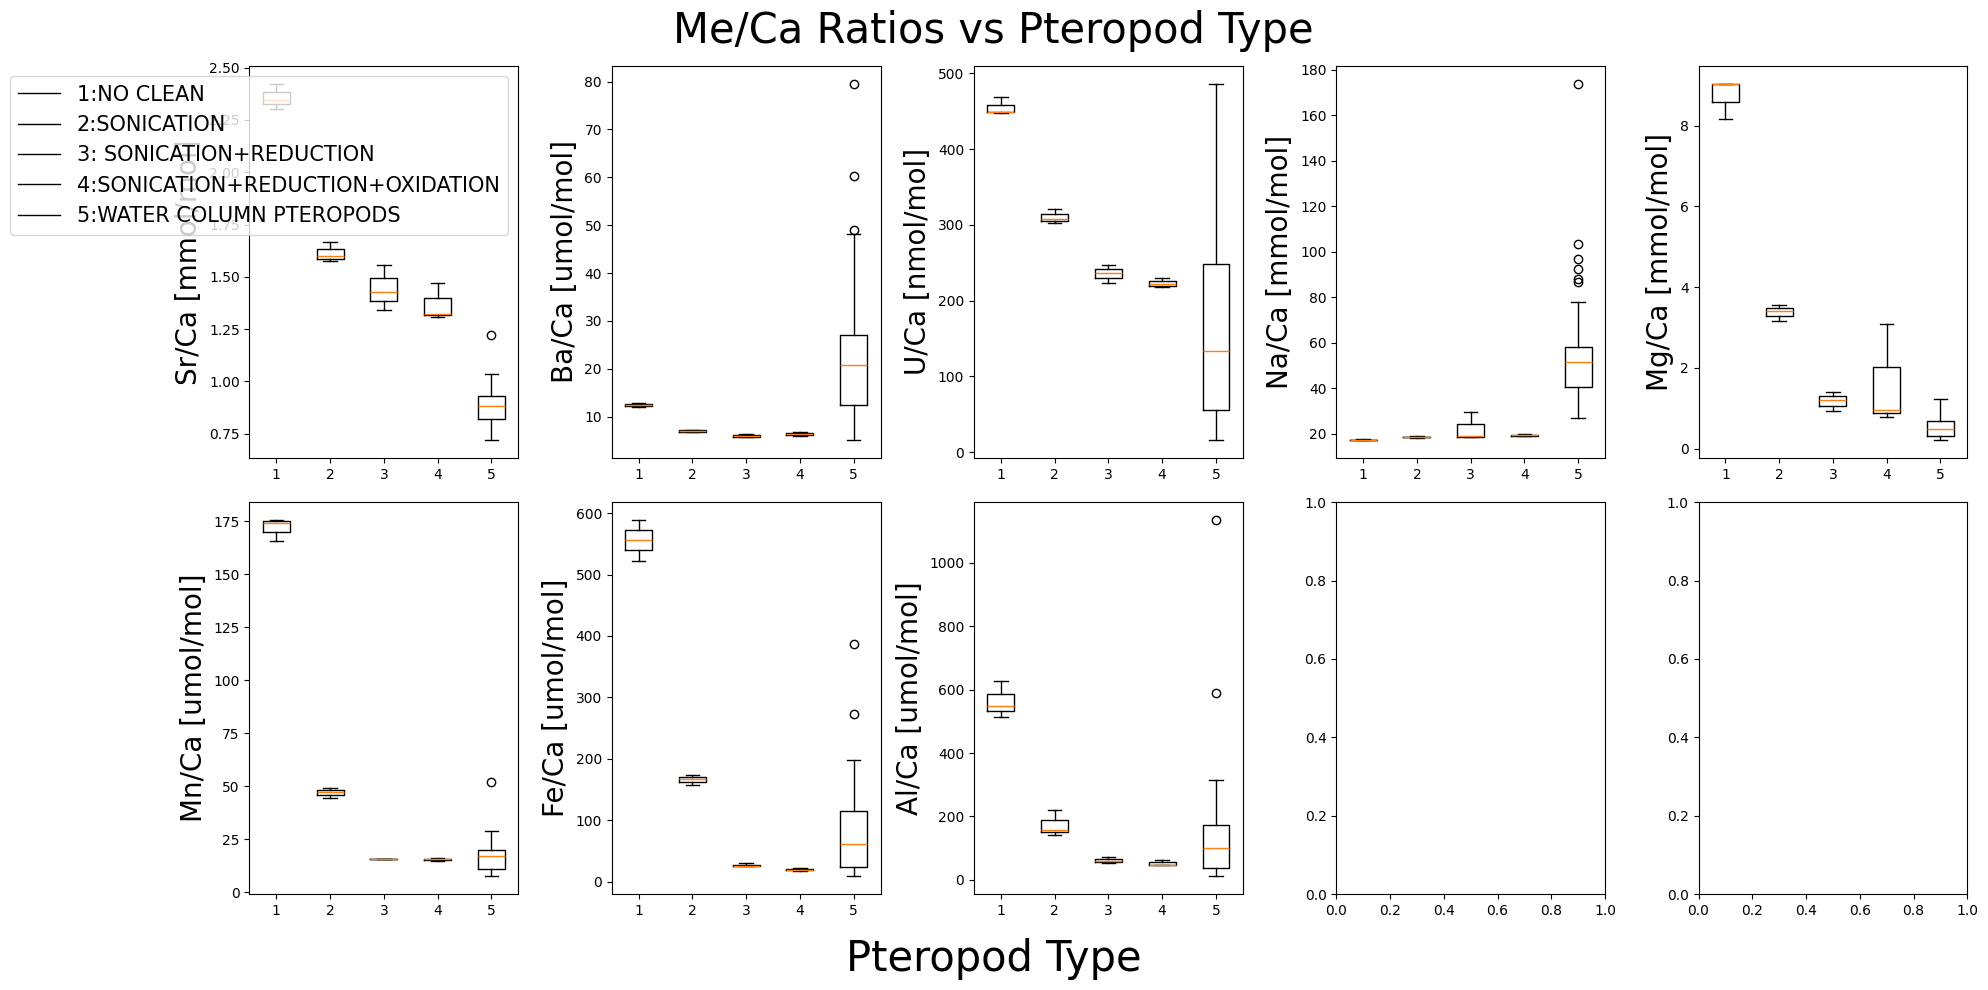

In [80]:
#Graph 2: combined Me/Ca ratios vs different cleaning types sedimentary pterods and water column pteropods 

#create figure
fig, axes = plt.subplots(2, 5, figsize=(30,), sharex=False, sharey=False)


#plot boxplots for combined data
axes[0,0].boxplot(cleantypeSr)

axes[0,1].boxplot(cleantypeBa)

axes[0,2].boxplot(cleantypeU)

axes[0,3].boxplot(cleantypeNa)

axes[0,4].boxplot(cleantypeMg)

axes[1,0].boxplot(cleantypeMn)

axes[1,1].boxplot(cleantypeFe) 

axes[1,2].boxplot(cleantypeAl)

#label axes
axes[0,0].set_ylabel('Sr/Ca [mmol/mol]', fontsize=20)
axes[0,0].set_xlabel('')

axes[0,1].set_ylabel('Ba/Ca [umol/mol]', fontsize=20)
axes[0,1].set_xlabel('')

axes[0,2].set_ylabel('U/Ca [nmol/mol]', fontsize=20)
axes[0,2].set_xlabel('')

axes[0,3].set_ylabel('Na/Ca [mmol/mol]', fontsize=20)
axes[0,3].set_xlabel('')

axes[0,4].set_ylabel('Mg/Ca [mmol/mol]', fontsize=20)
axes[0,4].set_xlabel('')

axes[1,0].set_ylabel('Mn/Ca [umol/mol]', fontsize=20)
axes[1,0].set_xlabel('')

axes[1,1].set_ylabel('Fe/Ca [umol/mol]', fontsize=20)
axes[1,1].set_xlabel('')

axes[1,2].set_ylabel('Al/Ca [umol/mol]', fontsize=20)
axes[1,2].set_xlabel('')

#plot title
fig.suptitle('Me/Ca Ratios vs Pteropod Type', fontsize = 30)
fig.supxlabel('Pteropod Type', fontsize= 30)
# fig.supylabel('Me/Ca Ratios', fontsize= 30)
lab = '1:NO CLEAN', '2:SONICATION', '3: SONICATION+REDUCTION', '4:SONICATION+REDUCTION+OXIDATION', '5:WATER COLUMN PTEROPODS'
#set legend
axes[0,0].legend(lab, fontsize = 15)

#fixing spacing layout
fig.tight_layout()

#add grid lines
# ax1.grid()

